In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Social_Network_Ads.csv')

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


# gradient descent
neural network train krte waqt loss minimize krne ka algorithm
Core Concept — Gradient Descent kya karta hai?
models ke weights/biases ko update krta hai taki loss kam ho
W_new = W_old − α × (∂Loss / ∂W)
α = learning rate (step size)
(∂Loss / ∂W)->gradient , slope of loss

Goal: loss function ka minimum point dhundho 

# Batch GD
Vanilla GD
pura data ek sath 1 epoch -> 1 update . batch_size=n_rows, smooth slow to converge

# Stochastic GD 
ek point ek baar 1 epoch -> no of rows times update, batch size=1,Noisy fast convergence

# Mini GD 
most used

Chote-chote batches , 1 epoch → n_batches updates
batch_size = 32/64/128 , Best of both worlds


In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df=df[['Age','EstimatedSalary','Purchased']]

In [6]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


1. Batch Gradient Descent
batch_size = n Pura dataset ek hi baar use karo, phir ek update.

Pseudo-code for epoch in range(num_epochs): y_hat = X.dot(W) + b # saare rows ka prediction ek saath (vectorization) loss = mean( (y_hat - y)² ) # sirf EK baar weights update W = W - lr * dL_dW b = b - lr * dL_db # weight updates per epoch = 1


Key points
✅ Smooth convergence — loss curve seedhi neeche jaati hai
✅ Vectorization possible — fast per epoch
❌ Slow to reach solution — updates bahut kam hote hain
❌ Large datasets pe fit nahi hoga RAM mein

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [8]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [9]:
pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import matplotlib.pyplot as plt

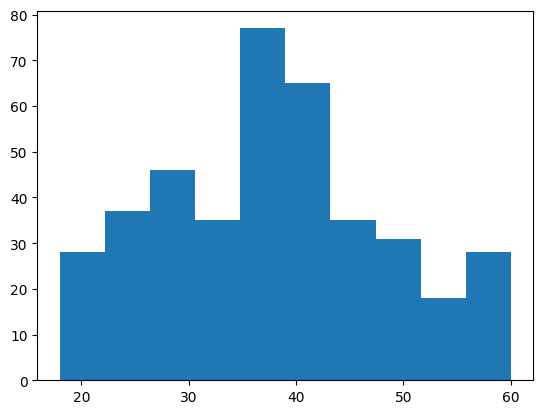

In [11]:
plt.hist(df['Age'])
plt.show()

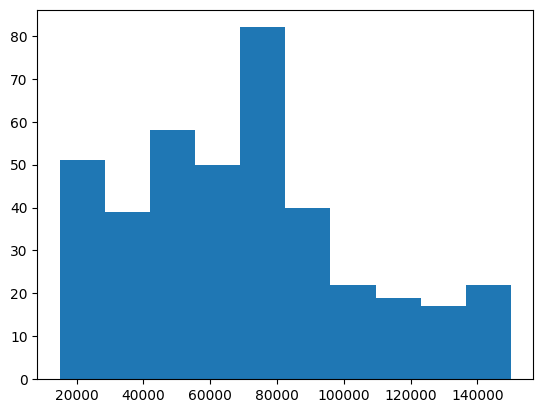

In [12]:
plt.hist(df['EstimatedSalary'])
plt.show()

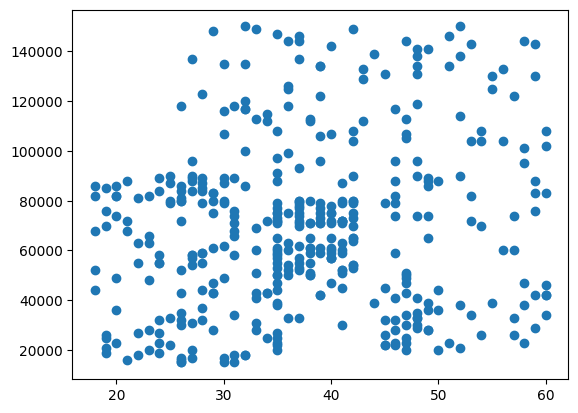

In [13]:
# Age vs Salary
plt.scatter(
    df['Age'],
    df['EstimatedSalary']
)
plt.show()

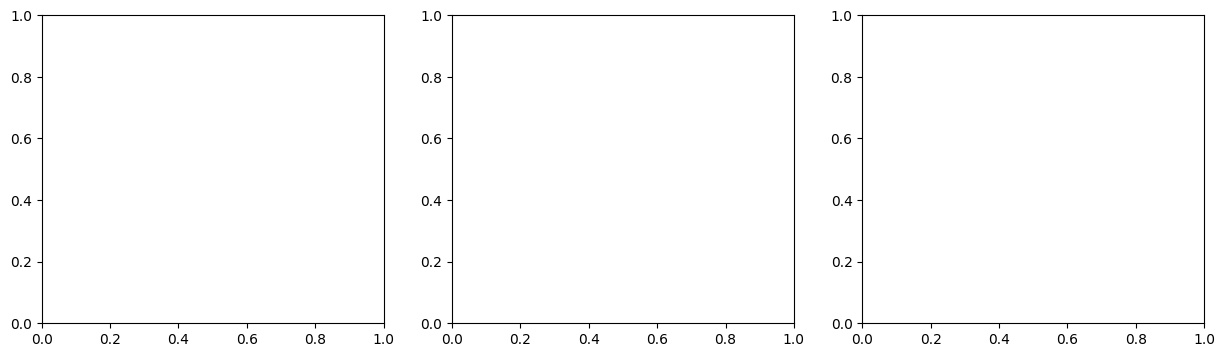

In [14]:
fig,axes=plt.subplots(1,3,figsize=(15,4))

In [15]:
axes[0]

<Axes: >

In [16]:
axes[0].hist(df[df['Purchased']==0]['Age'],bins=20)


(array([19.,  9., 15., 22., 22., 18., 14., 13., 36., 25., 21., 25.,  2.,
         6.,  3.,  3.,  2.,  0.,  0.,  2.]),
 array([18.  , 20.05, 22.1 , 24.15, 26.2 , 28.25, 30.3 , 32.35, 34.4 ,
        36.45, 38.5 , 40.55, 42.6 , 44.65, 46.7 , 48.75, 50.8 , 52.85,
        54.9 , 56.95, 59.  ]),
 <BarContainer object of 20 artists>)

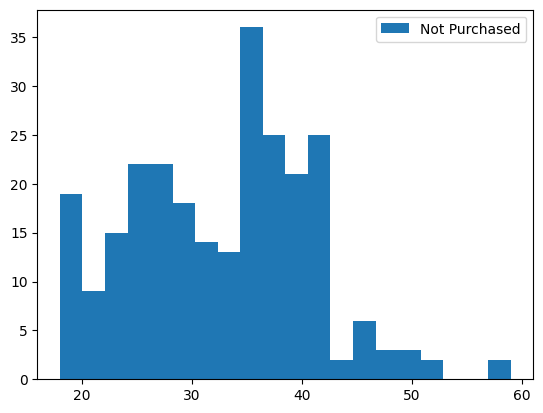

In [17]:
plt.hist(df[df['Purchased']==0]['Age'],bins=20,label='Not Purchased')
plt.legend()
plt.show()

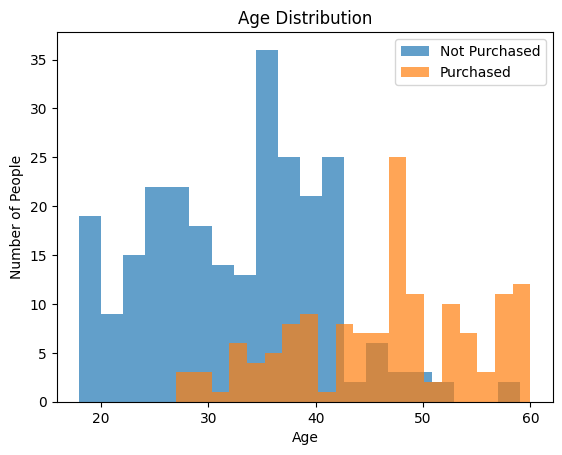

In [18]:
plt.hist(
    df[df['Purchased']==0]['Age'],
    bins=20,
    alpha=0.7,
    label='Not Purchased'
)

plt.hist(
    df[df['Purchased']==1]['Age'],
    bins=20,
    alpha=0.7,
    label='Purchased'
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.legend()
plt.show()

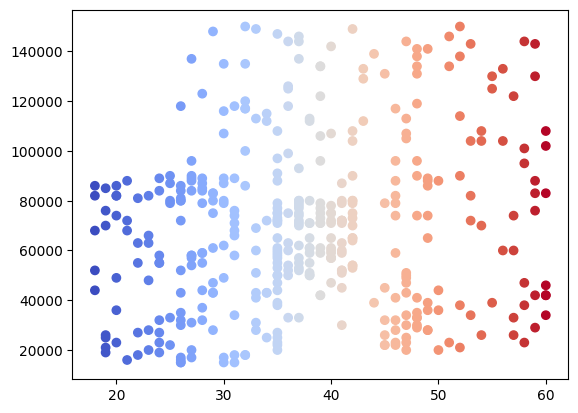

In [19]:
plt.scatter(df['Age'], df['EstimatedSalary'],c=df['Age'],cmap='coolwarm')

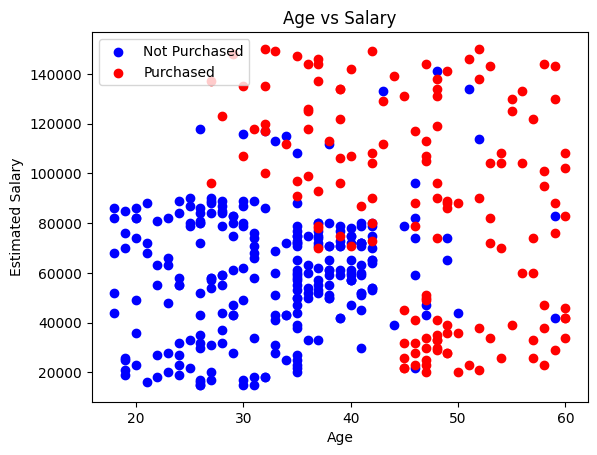

In [20]:
not_purchased = df[df['Purchased'] == 0]
purchased = df[df['Purchased'] == 1]

plt.scatter(
    not_purchased['Age'],
    not_purchased['EstimatedSalary'],
    color='blue',
    label='Not Purchased'
)

plt.scatter(
    purchased['Age'],
    purchased['EstimatedSalary'],
    color='red',
    label='Purchased'
)

plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Age vs Salary')

plt.legend()
plt.show()

## 4. Preprocessing — Feature Scaling & Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
X=df.iloc[:,0:2]

In [24]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [25]:
y=df.iloc[:,-1]

In [26]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [27]:
scaler=StandardScaler()

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
X_train_sc=scaler.fit_transform(X_train)

In [30]:
X_test_sc=scaler.transform(X_test)

In [31]:
X_test.shape

(80, 2)

In [32]:
y_test.shape

(80,)

In [33]:
X_train.shape

(320, 2)

In [34]:
X_train.head()

,Age,EstimatedSalary
3,27,57000
18,46,28000
202,39,134000
250,44,39000
274,57,26000


In [35]:
X_test.head()

,Age,EstimatedSalary
209,46,22000
280,59,88000
33,28,44000
210,48,96000
93,29,28000


# Neural Network
Architecture=2->4->1
Activation -> Sigmoid
Loss->Binary Cross entropy

TensorFlow
    ↓
Keras
    ↓
Sequential Model
    ↓
Dense Layers

In [36]:
!pip install tensorflow


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
pip install tensorflow keras


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
pip uninstall tensorflow keras tf-keras -y

Found existing installation: tensorflow 2.21.0Note: you may need to restart the kernel to use updated packages.

Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Found existing installation: keras 3.12.2
Uninstalling keras-3.12.2:
  Successfully uninstalled keras-3.12.2
Found existing installation: tf_keras 2.21.0
Uninstalling tf_keras-2.21.0:
  Successfully uninstalled tf_keras-2.21.0


In [39]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.Collecting tensorflow
  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached keras-3.12.2-py3-none-any.whl.metadata (5.9 kB)
Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
Using cached keras-3.12.2-py3-none-any.whl (1.5 MB)



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.12.2 which is incompatible.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.35.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
pip install tf-keras

  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tf_keras-2.21.0-py3-none-any.whl (1.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

Sequential Model = Layers ko ek sequence (line) me arrange karna.

Input
  ↓
Layer 1
  ↓
Layer 2
  ↓
Output

In [42]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2)) #First Hidden Layer, 10 neurons
# input_dim=2 because Age and EstimatedSalary are the two input features
# ReLU activation is used to learn complex patterns
model.add(Dense(10,activation='relu'))
# Second Hidden Layer
# Again 10 neurons
# Receives output from previous layer
# ReLU activation is used

model.add(Dense(10, activation='relu'))
model.add(Dense(1,activation='sigmoid'))
#Sigmoid Activation ->0 se 1 ke beech

c:\Users\iaman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

dense (Dense)     (None,10)     30
Output Shape:
(None,10) means layer has 10 neurons.
None represents batch size.

Parameters:
(inputs × neurons) + biases

Layer 1:
(2 × 10) + 10 = 30

Layer 2:
(10 × 10) + 10 = 110

Layer 3:
(10 × 10) + 10 = 110

Output Layer:
(10 × 1) + 1 = 11

Total Parameters:
30 + 110 + 110 + 11 = 261
261-> Ye saare weights aur biases training ke time update honge.

Gradient Descent inhi values ko change karega.

## 13. Summary Table

| | Batch GD | SGD | Mini-Batch GD |
|---|---|---|---|
| `batch_size` | = n (full data) | = 1 | 32 / 64 / 128 |
| Updates per epoch | 1 | n_rows | ceil(n/batch_size) |
| Speed per epoch | ✅ Fastest | ❌ Slowest | Medium |
| Convergence speed | ❌ Slowest | ✅ Fastest | Medium |
| Loss curve | Smooth | Noisy | Slightly noisy |
| RAM usage | ❌ High | ✅ Very low | ✅ Low |
| Local minima escape | ❌ No | ✅ Yes (via noise) | Partial |
| Vectorization | ✅ Yes | ❌ No | ✅ Yes |
| **Real-world use** | Rare | Rare | **⭐ Standard** |

### Weight Updates Formula:
```
Batch GD    → updates = epochs × 1
SGD         → updates = epochs × n_rows
Mini-Batch  → updates = epochs × ceil(n_rows / batch_size)
```

### Key Insight:
- **Batch GD** = smoothest path, ek update per epoch, slow to converge
- **SGD** = fastest convergence, but noisy aur approximate solution
- **Mini-Batch GD** = best of both → **yahi use karo hamesha**

> Tip: `batch_size` hamesha 2 ki power mein rakho (32, 64, 128, 256) — RAM efficiently use hoti hai.


In [44]:
# Compile Model

# binary_crossentropy:
# Used for binary classification (0 or 1)

# accuracy:
# Shows percentage of correct predictions

model.compile(
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model

# X_scaled -> input features
# y -> target values

# epochs=500
# Dataset is seen 500 times

# batch_size=1
# Weight update after every training example

# validation_split=0.2
# 80% training data
# 20% validation data

history = model.fit(
    X_train_sc,
    y_train,
    epochs=70,
    batch_size=1,
    validation_split=0.2
)

Epoch 1/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.8047 - loss: 0.5345 - val_accuracy: 0.8438 - val_loss: 0.3940
Epoch 2/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 46s 172ms/step - accuracy: 0.8477 - loss: 0.3771 - val_accuracy: 0.8906 - val_loss: 0.3124
Epoch 3/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8672 - loss: 0.3146 - val_accuracy: 0.8750 - val_loss: 0.2884
Epoch 4/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8867 - loss: 0.2897 - val_accuracy: 0.8750 - val_loss: 0.2882
Epoch 5/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8906 - loss: 0.2825 - val_accuracy: 0.8750 - val_loss: 0.2941
Epoch 6/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9062 - loss: 0.2703 - val_accuracy: 0.8750 - val_loss: 0.3023
Epoch 7/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9102 - loss: 0.2666 - val_accuracy: 0.8906 - val_loss: 0.3147
Epoch 8/70
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9102 - loss: 0.2664 - val_

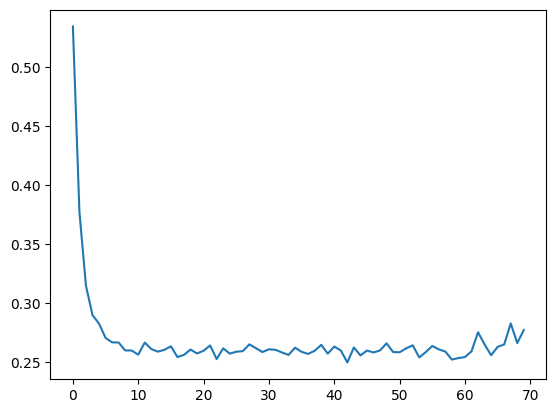

In [45]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

Raw Data
    ↓
Train-Test Split
    ↓
Fit Scaler on Train Only
    ↓
Transform Train
    ↓
Transform Test
    ↓
Train Model on X_train_scaled
    ↓
Evaluate on X_test_scaled

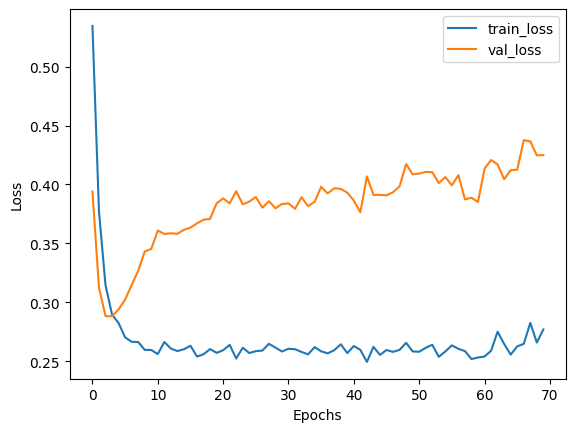

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['train_loss','val_loss'])

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

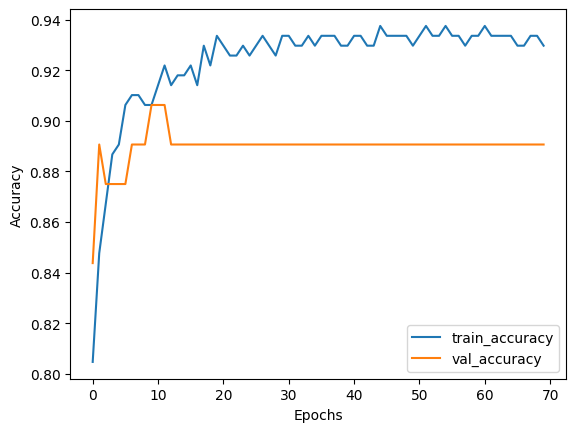

In [47]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['train_accuracy','val_accuracy'])

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

In [48]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [49]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [50]:
print(type(model))
print(type(early_stop))

<class 'keras.src.models.sequential.Sequential'>
<class 'keras.src.callbacks.early_stopping.EarlyStopping'>


In [51]:
history = model.fit(
    X_train_sc,
    y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9375 - loss: 0.2577 - val_accuracy: 0.8906 - val_loss: 0.4183
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9336 - loss: 0.2544 - val_accuracy: 0.8906 - val_loss: 0.4118
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9336 - loss: 0.2504 - val_accuracy: 0.8906 - val_loss: 0.4043
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9336 - loss: 0.2462 - val_accuracy: 0.8906 - val_loss: 0.3969
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9336 - loss: 0.2424 - val_accuracy: 0.8906 - val_loss: 0.3883
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9336 - loss: 0.2376 - val_accuracy: 0.8906 - val_loss: 0.3793
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9336 - loss: 0.2335 - val_accuracy: 0.8906 - val_loss: 0.3704
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9336 - loss: 0.2301 - val_accuracy: 0.8906 - val_loss

In [52]:
from keras.callbacks import EarlyStopping

Apply Early Stopping when:

1. Validation loss stops decreasing.
2. Validation loss starts increasing.
3. Validation accuracy becomes stagnant.
4. Training loss keeps decreasing but validation performance does not improve.

This helps prevent overfitting and reduces unnecessary training time.

In [53]:
model.evaluate(X_test_sc, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9375 - loss: 0.1809


[0.18091218173503876, 0.9375]

In [54]:
y_prob = model.predict(X_test_sc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


Probability ko Class me Convert Karo

In [55]:
y_pred = (y_prob > 0.5).astype(int)

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[48  4]
 [ 1 27]]


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        52
           1       0.87      0.96      0.92        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



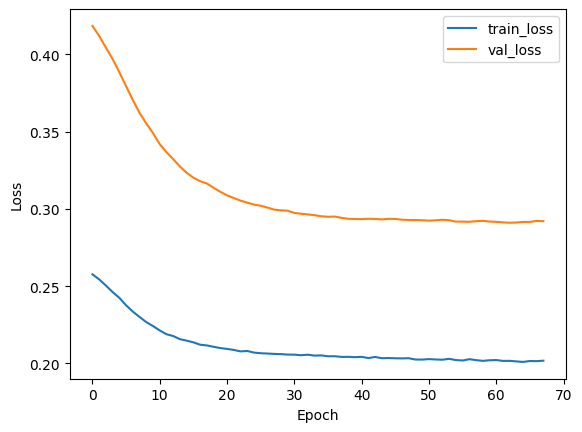

In [58]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['train_loss','val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [59]:
import os
print(os.path.abspath("gradient_descent.ipynb"))

c:\Users\iaman\100-days-of-deep-learning\gradient_descent.ipynb
